In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 51.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=aa3310aa1c0f968e0455d372f104efd1d068386b1abb8c58aaadc28563f1544a
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
# Deutsch's algorithm
# Given an unknown function f : {0,1} -> {0,1},
# work out whether it is constant or balanced.

# There are four possible functions:
#
# (constant) f always outouts 0, or always outputs 1 (f0, f1)
# f0 is constant 0
# f1 is constant 1

# (balanced) f outputs 0 for one input and and 1 for the other (f2, f3)
# f2 is the identity
# f3 is negation

# Deutsch's algorithm works with F, a quantum version of f, defined by
# |x> -> qubit 1, |y> -> qubit 0 # Qiskit numbers qubits right to left
# F|x>|y> = |x>|f(x) XOR y>
#
# Explicitly define F0, F1, F2, F3 as circuits and convert them to gates.

# F0 |x>|y> = |x>|y> so it's the identity function.
F0_circuit = QuantumCircuit(2)  # no gates needed
#  (y unchanged, f(x)=0, XOR with 0 changes nothing -> Identity circuit)
F0 = circuit_to_gate(F0_circuit,label="F0")

# F1 |x>|y> = |x>|NOT(y)> so it's implemented by applying X(y).
F1_circuit = QuantumCircuit(2)
# Remember that numbering of qubits starts from the right.
F1_circuit.x(0)  # flips qubit 0 (y register)
F1 = circuit_to_gate(F1_circuit,label="F1")

# F2 |x>|y> = |x>|x XOR y>. Work out how to implement it as a circuit.
F2_circuit = QuantumCircuit(2)
# Add a gate to F2_circuit so that the function F2 is correctly implemented.
# Remember that numbering of qubits starts from the right.
F2_circuit.cx(1, 0)  # CNOT gate, [control(q1)=x, target(q0)=y]
F2 = circuit_to_gate(F2_circuit,label="F2")

# F3 |x>|y> = |x>|NOT(x) XOR y>. Work out how to implement it as a circuit.
F3_circuit = QuantumCircuit(2)
# Add gates to F3_circuit so that the function F3 is correctly implemented.
# Remember that numbering of qubits starts from the right.
F3_circuit.x(1)  # flip X to qubits 1 (x) to get NOT(x)
F3_circuit.cx(1, 0)  # CNOT: if NOT(x)=1, flip y
F3_circuit.x(1)  # un-flip x back to original

F3 = circuit_to_gate(F3_circuit,label="F3")

In [36]:
# Choose which function we want to analyse

F = F1  # diff F circults results in different qubits

In [37]:
# Check that F is implemented correctly
# In this cell and the next three, make sure you understand why your
# definition of F is correct (or not).
# Test on |00> - no X gate
test = QuantumCircuit(2)
test.append(F,[0,1])
state = Statevector.from_int(0, 4) # 4 basis states on 2 qubits
state = state.evolve(test)
state.draw("latex")

<IPython.core.display.Latex object>

In [38]:
# Test on |01>
test = QuantumCircuit(2)
test.x(0) # flip qubit 0 (y) only
test.append(F,[0,1])
state = Statevector.from_int(0, 4) # 4 basis states on 2 qubits
state = state.evolve(test)
state.draw("latex")

<IPython.core.display.Latex object>

In [39]:
# Test on |10>
test = QuantumCircuit(2)
test.x(1) # flip qubit 1 (x) only
test.append(F,[0,1])
state = Statevector.from_int(0, 4) # 4 basis states on 2 qubits
state = state.evolve(test)
state.draw("latex")

<IPython.core.display.Latex object>

In [40]:
# Test on |11>
test = QuantumCircuit(2)
# flip both qubits
test.x(0)
test.x(1)
test.append(F,[0,1])
state = Statevector.from_int(0, 4) # 4 basis states on 2 qubits
state = state.evolve(test)
state.draw("latex")

<IPython.core.display.Latex object>

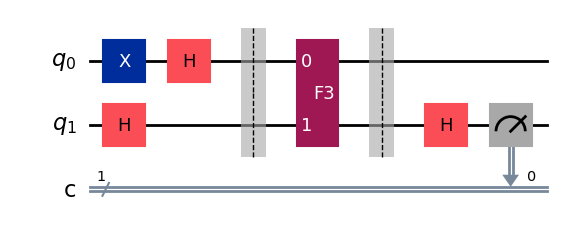

In [34]:
# The circuit for Deutsch's algorithm
# There are two qubits but we don't use them as inputs, just start them at |0>
# and manipulate them.
# One classical bit is used to capture the measurement result.
# Fill in the gaps to implement Deutsch's algorithm.

deutsch = QuantumCircuit(2,1)
# Add gates here to prepare the state that we want to apply F to
# Initialize qubit 0 (rightmost) to |1> and apply H to both qubits.
deutsch.x(0)  # prepare |01>
deutsch.h([0,1])  # apply hadamard to both qubits

deutsch.barrier()

deutsch.append(F,[0,1])

deutsch.barrier()
# Add a gate and a measurement here to complete the circuit
deutsch.h(1)  # apply hadamard to the first qubit and measure
deutsch.measure(1,0)
deutsch.draw("mpl")

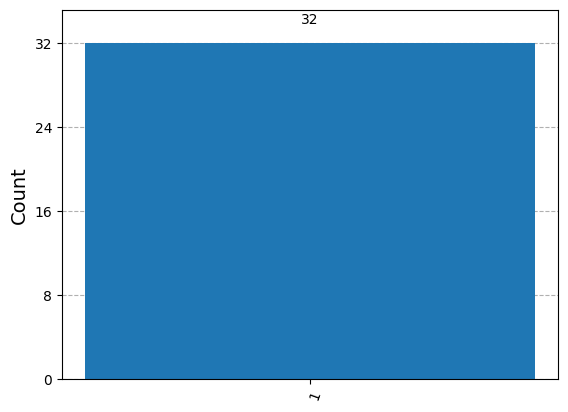

In [35]:
# Now simulate and plot the results.
# If f is constant (that is, F0 or F1) the result should always be 0.
# if f is balanced (that is, F2 or F3) the result should always be 1.

backend = BasicSimulator()
compiled = transpile(deutsch, backend)
job_sim = backend.run(compiled, shots=32) # runs the circuit 32 times
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
plot_histogram(counts)